In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import json
from PIL import Image
import cv2
from glob import glob
from tqdm import tqdm

from maskrcnn_benchmark.config import cfg
from maskrcnn_benchmark.engine.predictor_glip import GLIPDemo

## 1. 功能函数的定义

In [4]:
def xyxy_to_xywh(coords):
    x1 = coords[0]
    y1 = coords[1]
    x2 = coords[2]
    y2 = coords[3]
    
    w = x2 - x1
    h = y2 - y1
    return [x1, y1, w, h]

def show_img(img, bboxes = None, tag = None, captions = None):
    '''
        Function: used to show image and corresponding bounding boxes.
    '''
    fig, ax = plt.subplots()
    
    ax.imshow(img)
    
    if bboxes is not None:
        for i, bbox in enumerate(bboxes):
            x, y, w, h = bbox
            rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            
            if tag is not None:
                ax.text(x, y-8, str(i+1), color='r', fontsize=11, weight='bold')
            if captions is not None:
                ax.text(x+20, y-8, captions[i], color='r', fontsize=11, weight='bold')
    plt.axis("off")
    plt.show()

In [3]:
def load_glip(config_file, weight_file):
    '''
        Function: used to load glip model.
    '''
    cfg.local_rank = 0
    cfg.num_gpus = 1

    cfg.merge_from_file(config_file)
    cfg.merge_from_list(["MODEL.WEIGHT", weight_file])
    cfg.merge_from_list(["MODEL.DEVICE", "cuda"])
    
    glip_demo = GLIPDemo(
        cfg, 
        min_image_size=800,
        confidence_threshold=0.7,
        show_mask_heatmaps=False,
    )
    glip_demo.color = 255
    return glip_demo

def glip_processor(glip_model, img, caption, thresh):
    '''
        glip_model: the return of load_glip function.
        img: PIL Image format
    '''
    
    # 1. 处理图片:
    img_np = np.array(img)[:,:,[2,1,0]]
    
    _, pred, inference_time = glip_demo.run_on_web_image(
        original_image = img_np,
        original_caption = caption,
        thresh = thresh,
    )
    
    captions = caption.replace(" ","").split(".")
    
    bboxes = pred.bbox.numpy().astype(np.int64).tolist()
    areas = pred.area().tolist()
    labels = (pred.get_field("labels").numpy() - 1).tolist()
    scores = pred.get_field("scores").tolist()
    
    new_outcome = []
    for bbox, area, label, score in zip(bboxes, areas, labels, scores):
        new_outcome.append({
            "bbox":xyxy_to_xywh(bbox),
            "area":area,
            "label":captions[label],
            "score":score
        })
    
    return new_outcome, pred.size, inference_time

## 2. 测试代码

In [6]:
## 获取glip_demo
config_file = "./vgms/glip/configs/pretrain/glip_Swin_L.yaml"
weight_file = "./vgms/glip/weights/glip_large_model.pth"
glip_demo = load_glip(config_file=config_file, weight_file=weight_file)

VISION BACKBONE USE GRADIENT CHECKPOINTING:  False
LANGUAGE BACKBONE USE GRADIENT CHECKPOINTING:  False


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'bert.pooler.dense.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'bert.pooler.dense.bias', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


EARLY FUSION ON, USING MHA-B
EARLY FUSION ON, USING MHA-B
EARLY FUSION ON, USING MHA-B
EARLY FUSION ON, USING MHA-B
EARLY FUSION ON, USING MHA-B
EARLY FUSION ON, USING MHA-B
EARLY FUSION ON, USING MHA-B
EARLY FUSION ON, USING MHA-B


In [48]:
# 测试代码
thresh = 0.35
img_path = "./imgs/dataset/2. working at height/2_1_136.jpg"
img = Image.open(img_path).convert("RGB")
caption = "worker ."


outcome, image_size, inference_time = glip_processor(
    glip_model = glip_demo, 
    img = img, 
    caption = caption, 
    thresh = thresh
)

print(outcome)

[{'bbox': [58, 144, 204, 222], 'area': 45692.91796875, 'label': 'worker', 'score': 0.6812209486961365}, {'bbox': [297, 338, 55, 52], 'area': 2951.0458984375, 'label': 'worker', 'score': 0.36224353313446045}]


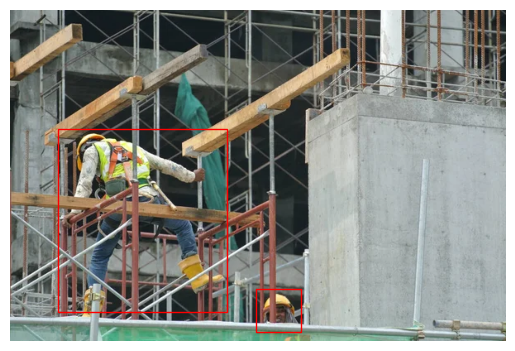

In [49]:
bboxes = [item["bbox"] for item in outcome ]
show_img(img, bboxes)

In [50]:
path_list = [
    "./imgs/dataset/1. gas cylinder/*.jpg",
    "./imgs/dataset/2. working at height/*.jpg",
    "./imgs/dataset/3. worker with hardhat & vest/*.jpg",
    "./imgs/dataset/4. working with eye protection/*.jpg",
    "./imgs/dataset/5. vehicle/*.jpg",
]
caption_list = [
    "cylinder .",
    "worker .",
    "worker .",
    "worker .",
    "excavator ."
]
thresh = 0.35

In [51]:
for j in range(len(path_list)):
    img_path_list = glob(path_list[j])
    print(f"The quantity of images: {len(img_path_list)}")
    caption = caption_list[j]
    print(caption)

    img_outcome = {}
    for i, img_path in tqdm(enumerate(img_path_list), total = len(img_path_list)):
        img = Image.open(img_path).convert("RGB")
        
        outcome, image_size, inference_time = glip_processor(
            glip_model = glip_demo, 
            img = img, 
            caption = caption, 
            thresh = thresh
        )
    
        img_outcome[i] = {
            "img_path":img_path,
            "img_size":image_size, #[width, height]
            "inference_time":inference_time,
            "result":outcome
        }
        
    with open(f"./results/glip_{j+1}.json", "w") as fp:
        fp.write(json.dumps(img_outcome))

The quantity of images: 305
cylinder .


100%|████████████████████████████████████████████████████████████████████████████████| 305/305 [07:12<00:00,  1.42s/it]


The quantity of images: 570
worker .


100%|████████████████████████████████████████████████████████████████████████████████| 570/570 [12:33<00:00,  1.32s/it]


The quantity of images: 439
worker .


100%|████████████████████████████████████████████████████████████████████████████████| 439/439 [10:35<00:00,  1.45s/it]


The quantity of images: 409
worker .


100%|████████████████████████████████████████████████████████████████████████████████| 409/409 [09:40<00:00,  1.42s/it]


The quantity of images: 837
excavator .


100%|████████████████████████████████████████████████████████████████████████████████| 837/837 [25:49<00:00,  1.85s/it]


In [34]:
# ## 处理图片获取visual grounding的结果
# img = Image.open("./imgs/testing.jpg").convert("RGB")
# caption = "cylinder . tank . "
# thresh = 0.4

# outcome, image_size, inference_time = glip_processor(
#     glip_model = glip_demo, 
#     img = img, 
#     caption = caption, 
#     thresh = thresh`
# )

## 3. 实验代码

In [ ]:
## 1. 获取glip_demo
config_file = "./vgms/glip/configs/pretrain/glip_Swin_L.yaml"
weight_file = "./vgms/glip/weights/glip_large_model.pth"
glip_demo = load_glip(config_file=config_file, weight_file=weight_file)

# 2. 定义参数
caption = "cylinder . tank . "
thresh = 0.4

In [25]:
img_path_list = glob("./imgs/*.jpg")
img_outcome = {}
for i, img_path in enumerate(img_path_list):
    img = Image.open(img_path).convert("RGB")
    
    outcome, image_size, inference_time = glip_processor(
        glip_model = glip_demo, 
        img = img, 
        caption = caption, 
        thresh = thresh
    )
    img_outcome[i] = {
        "img_path":img_path,
        "img_size":image_size, #[width, height]
        "inference_time":inference_time,
        "result":outcome
    }

In [27]:
with open(f"./results/glip_{1}.json", "w") as fp:
    fp.write(json.dumps(img_outcome))

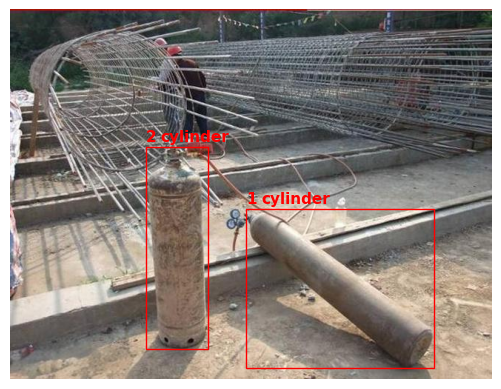

In [85]:
# show_img(
#     img=img,
#     bboxes=[[319, 270, 254, 215],[183, 186, 85, 273]],
#     tag=True, 
#     captions=['cylinder','cylinder']
# )